<a href="https://colab.research.google.com/github/Priyanka797/Exploratory-Data-Analysis-EDA-/blob/main/Logistic_Regression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project predicts whether a patient has diabetes based on health metrics like glucose, BMI, and blood pressure. Dataset: Pima Indians Diabetes (768 patients). The goal is to build and evaluate a logistic regression classifier.

In [1]:
# importing library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load dataset from GitHub
df = pd.read_csv('https://raw.githubusercontent.com/Priyanka797/machine-learning-projects/refs/heads/main/diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
# Explore dataset
df.head()
df.tail()
df.info()
df.describe()
df.shape
df.size
df.max
df.min

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


<bound method DataFrame.min of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  outcome  
0                       0.627   50        1  
1                       0.351   31        0  
2                       0.672   32        1  
3                       0.167   21        0  
4                       2.288   33        1  
..                        ...  ...      ...  
763                     0.171   63        0  
764                     0.340   27        0  
765                     0.245   30        0  
766                     0.349   47        1  
767                     0.315   23        0  

[768 rows x 9 columns]>

In [4]:
# Handling missing values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
outcome,0


In [5]:
# Handling duplicates values
print(f"The duplicate: {df.duplicated().sum()}")

The duplicate: 0


In [6]:
# Getting the count of unique values
print(df.nunique())

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
outcome                       2
dtype: int64


In [7]:
# Handle Missing or Invalid Zeros
cols_with_zero = ['Glucose', 'BloodPressure','Insulin', 'BMI']
for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_9239/1094057466.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [8]:
# dropping th User ID column
data_new = df.drop('SkinThickness',axis=1)
data_new.head()

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,outcome
0,6,148.0,72.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,168.0,43.1,2.288,33,1


In [9]:
# getting the independent and dependent variable
X = data_new.drop('outcome',axis=1)
Y = data_new[['outcome']]


In [10]:
# Splitting the data into train and test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.5, random_state=42)

In [11]:
# creating the object of  LinearRegression
lr = LogisticRegression()
# fitting the model(training the model)
lr.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [12]:
# Evaluating the model
print(lr.score(x_test, y_test))

0.78125


In [13]:
from sklearn.metrics import confusion_matrix

In [14]:
pred=lr.predict(x_test)

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
cm=confusion_matrix(y_test,pred)

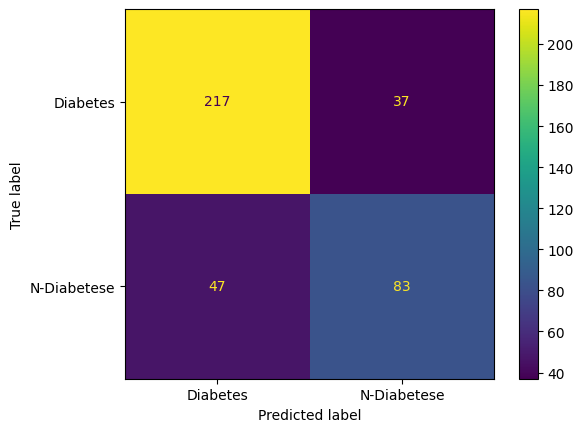

In [16]:
dis=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Diabetes','N-Diabetese'])
dis.plot()
plt.show()

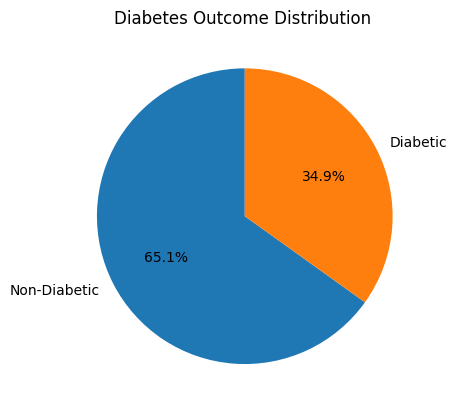

In [17]:
counts = df["outcome"].value_counts()

# Convert index to names
labels = ["Non-Diabetic" if i == 0 else "Diabetic" for i in counts.index]

plt.figure()
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Diabetes Outcome Distribution ")
plt.show()



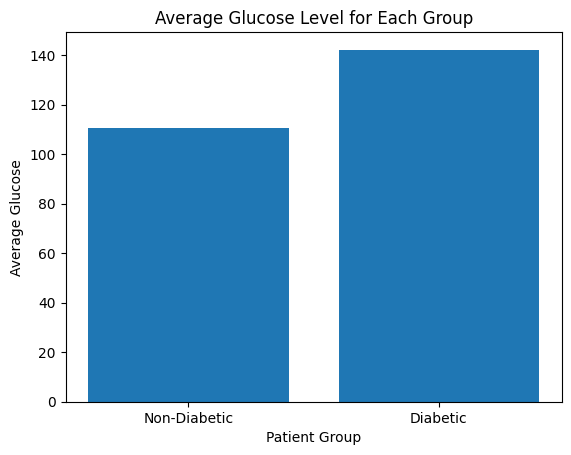

In [18]:
mean_glucose = df.groupby("outcome")["Glucose"].mean()

plt.figure()
plt.bar(["Non-Diabetic", "Diabetic"], mean_glucose.values)
plt.title("Average Glucose Level for Each Group")
plt.xlabel("Patient Group")
plt.ylabel("Average Glucose")
plt.show()


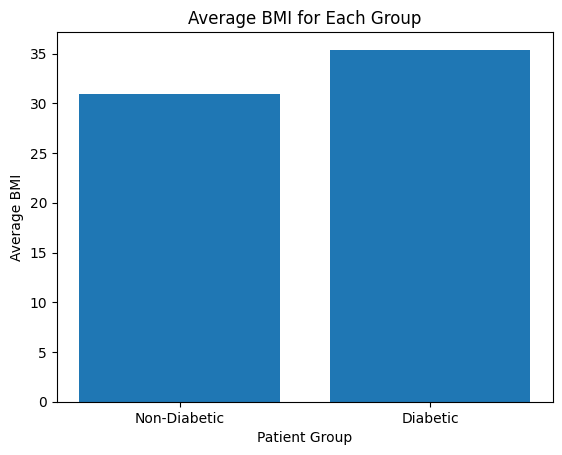

In [19]:
mean_bmi = df.groupby("outcome")["BMI"].mean()

plt.figure()
plt.bar(["Non-Diabetic", "Diabetic"], mean_bmi.values)
plt.title("Average BMI for Each Group")
plt.xlabel("Patient Group")
plt.ylabel("Average BMI")
plt.show()


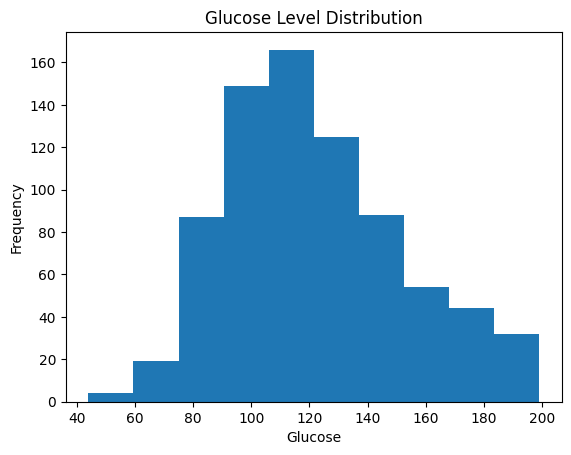

In [20]:
plt.figure()
plt.hist(df["Glucose"])
plt.title("Glucose Level Distribution")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()


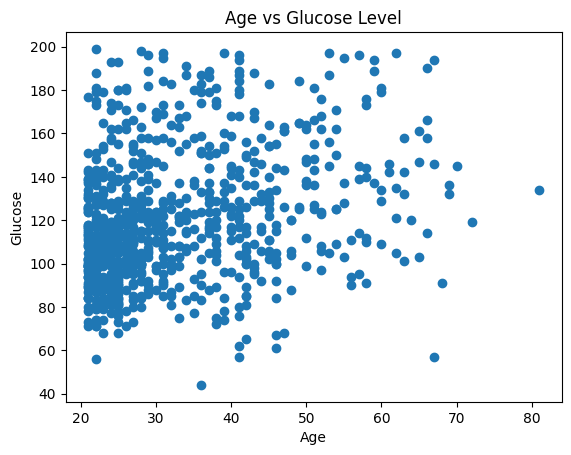

In [21]:
plt.figure()
plt.scatter(df["Age"], df["Glucose"])
plt.title("Age vs Glucose Level")
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.show()


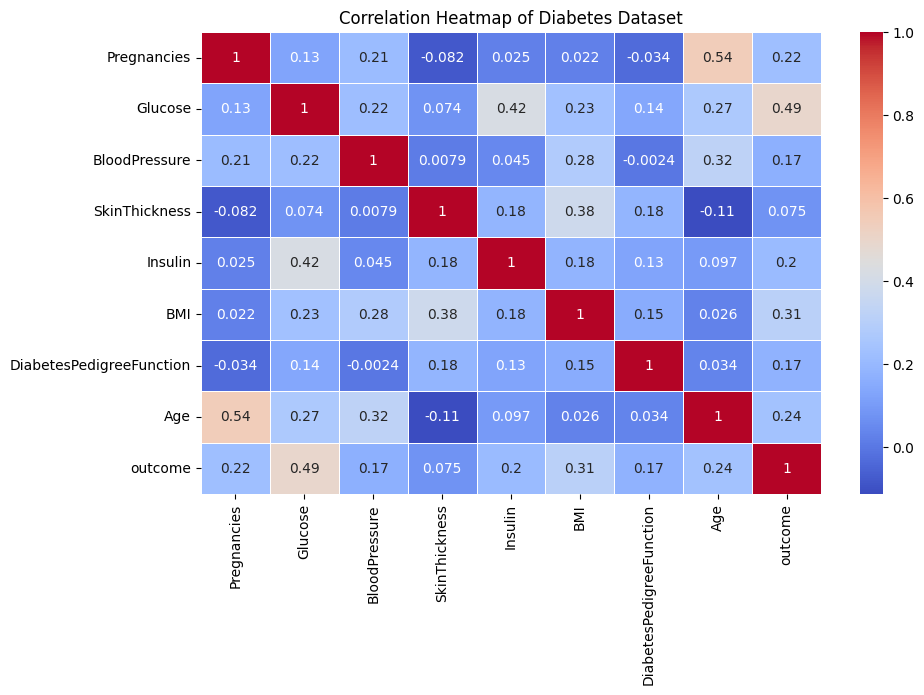

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, linewidths=.5, cmap="coolwarm")
plt.title("Correlation Heatmap of Diabetes Dataset")
plt.show()


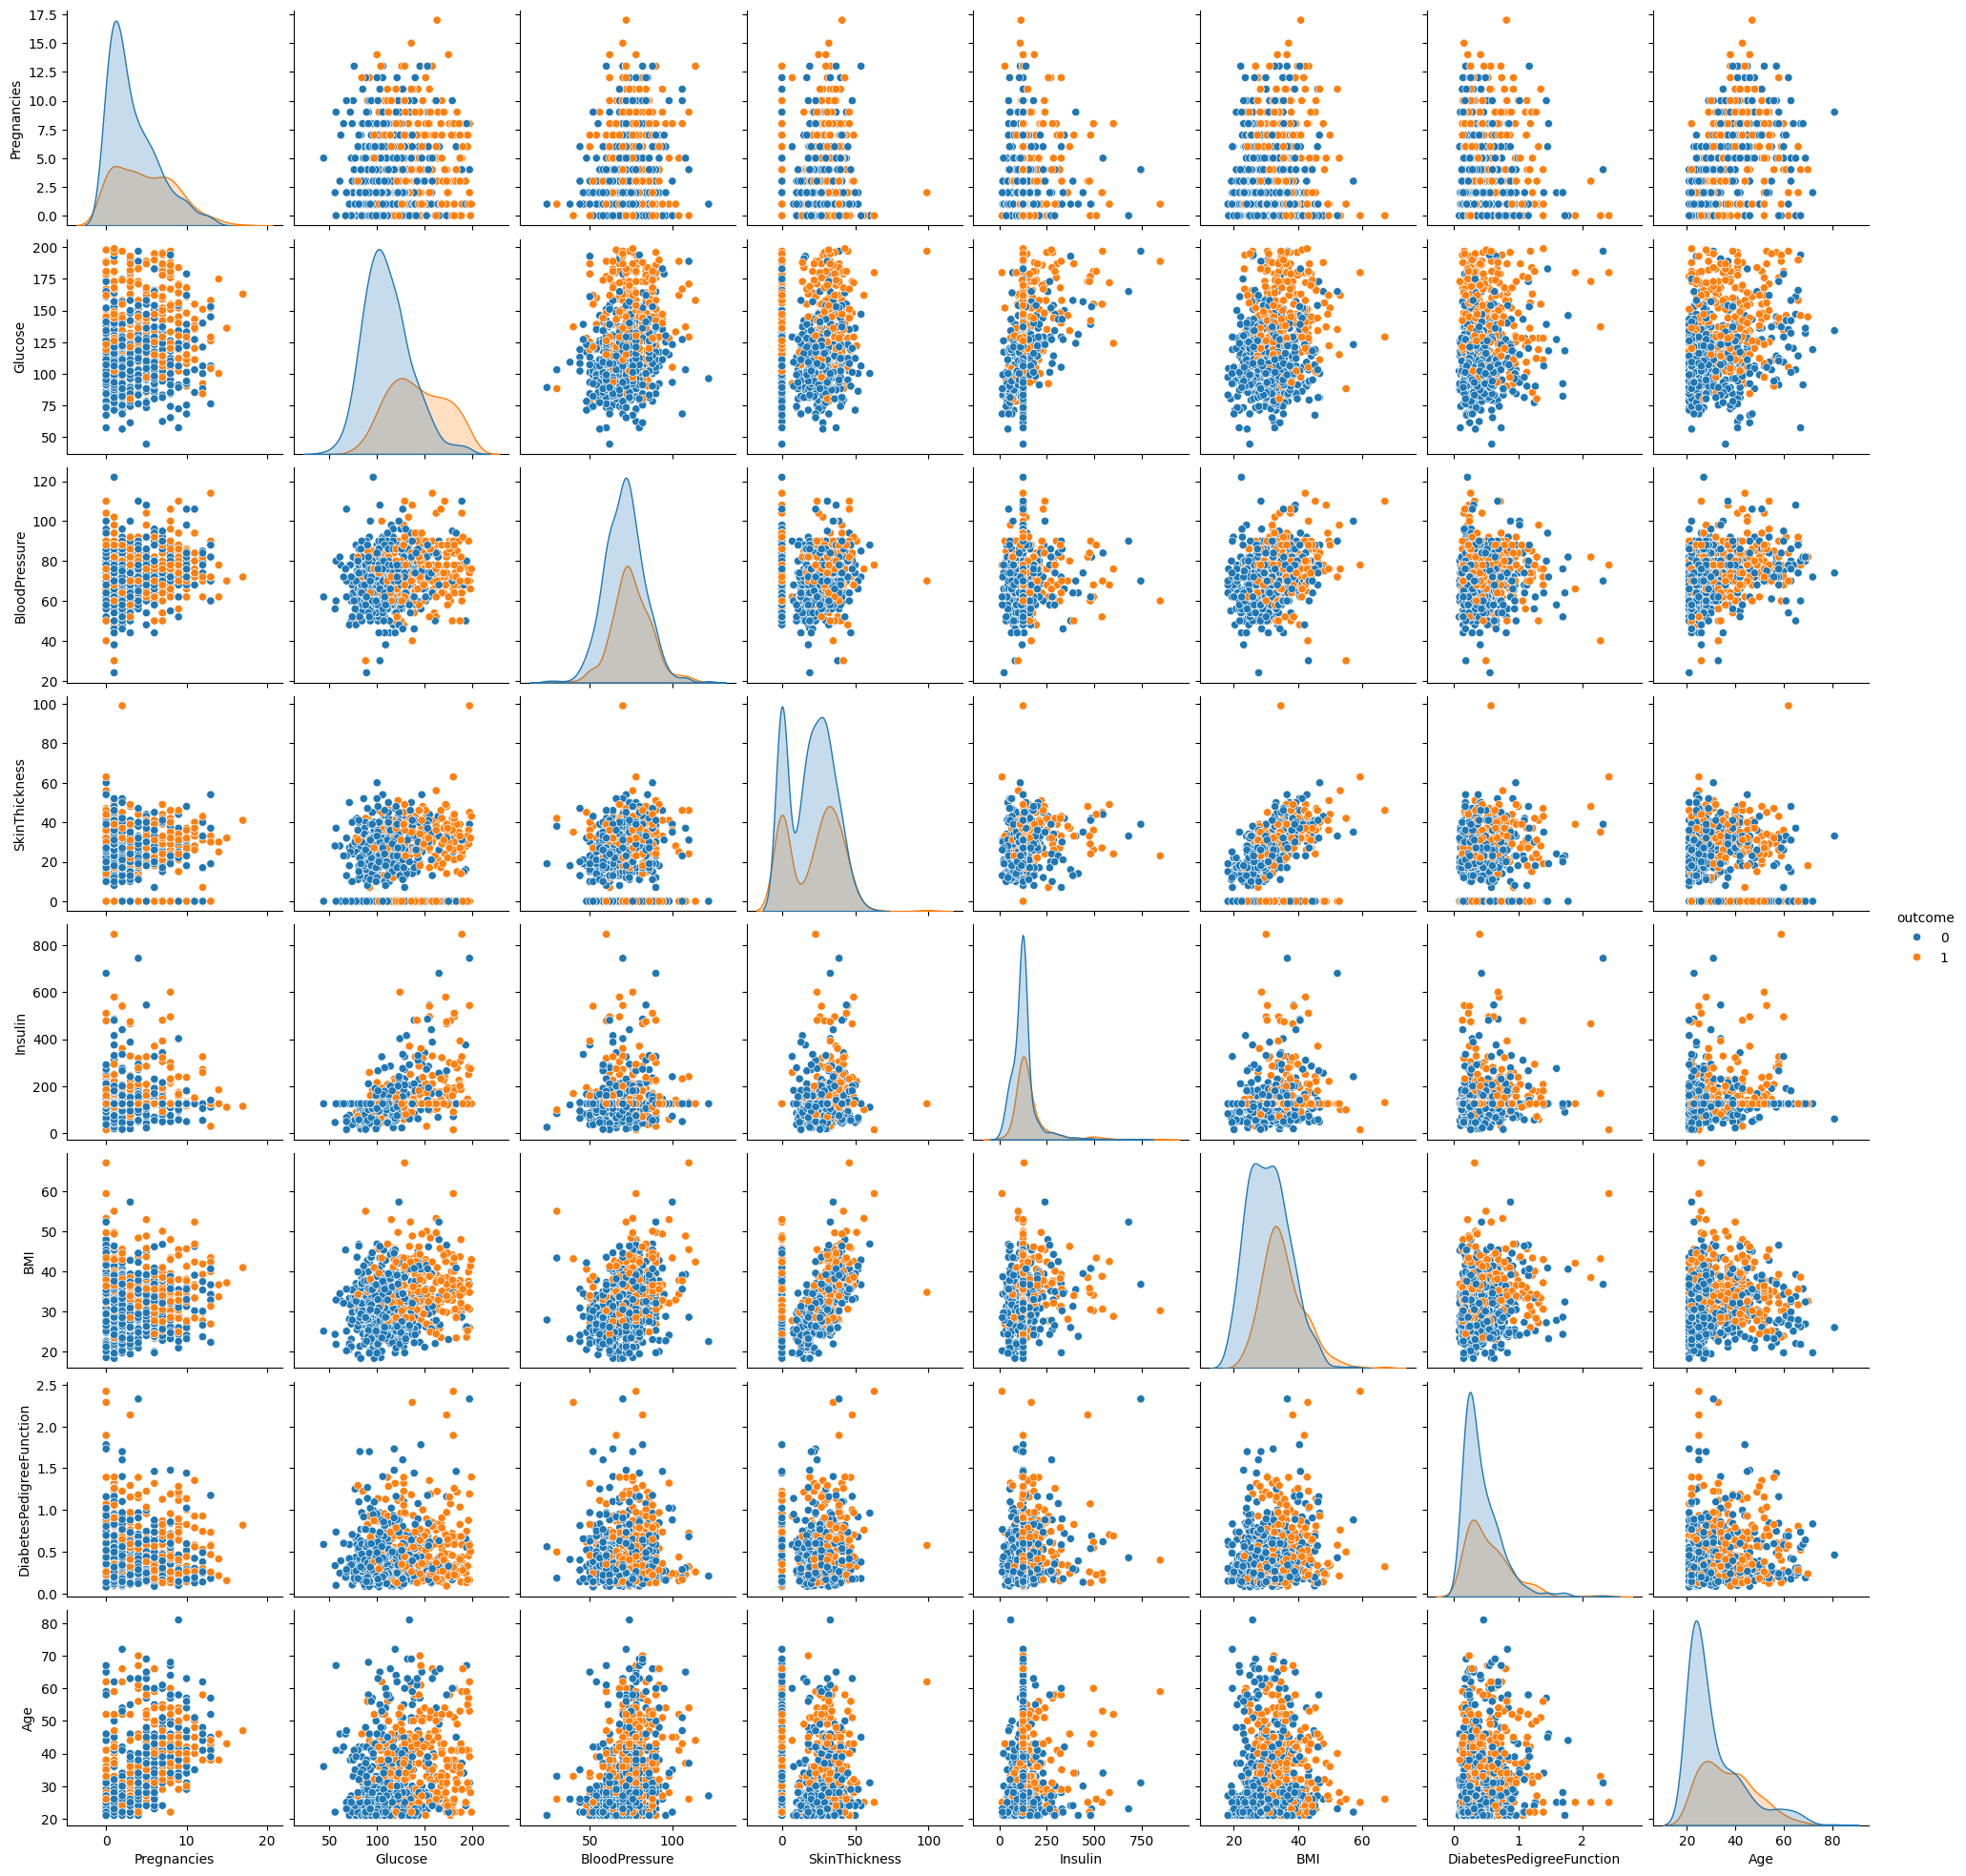

In [23]:
sns.pairplot(df, hue="outcome")
plt.show()


In [24]:
# Step 1: Import
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Step 2: Prepare data
X = df.drop("outcome", axis=1)
y = df["outcome"]

# Step 3: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Step 5: Predict
y_pred = model.predict(X_test)

# Step 6: Accuracy
print("Model Accuracy:", accuracy_score(y_test, y_pred))


Model Accuracy: 0.7662337662337663


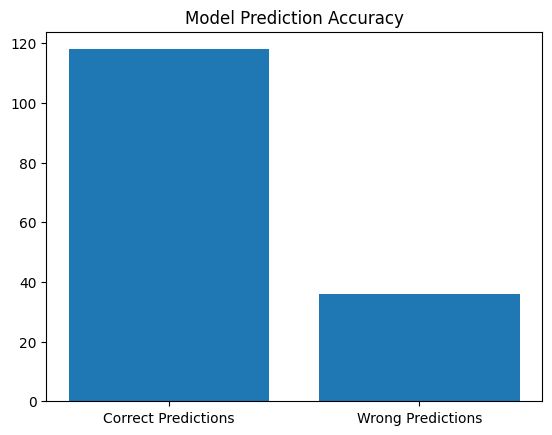

In [25]:
plt.figure()
plt.bar(["Correct Predictions", "Wrong Predictions"], [sum(y_pred==y_test), sum(y_pred!=y_test)])
plt.title("Model Prediction Accuracy")
plt.show()



Conclusion
The logistic regression model predicted diabetes with about 78% accuracy. Glucose and BMI showed the strongest correlation with the outcome.